# Antecedent ERA5 warming and RGI glacier slope

**Numerical question.** Among ten crosswalked documented glacier detachments/collapses and their 20 frozen matched RGI comparison objects, are strictly antecedent ERA5 trends and mixed-epoch RGI glacier-wide mean-slope attributes larger for the cases? This is a descriptive catalog comparison, not a probability sample, failure-risk model, source-zone reconstruction, or causal trigger test.

In [1]:
from pathlib import Path
import hashlib, json, matplotlib.pyplot as plt, numpy as np, pandas as pd
root=Path('..').resolve(); out=root/'data/glacier_warming_steepness'
manifest_path=out/'results_manifest.json'
assert hashlib.sha256(manifest_path.read_bytes()).hexdigest()=='ab80e5e165ee71e344c3b5b498f80e738e9cee59877e97669ea3e5345ef848ea'
manifest=json.loads(manifest_path.read_text())
for name,record in manifest['outputs'].items(): assert hashlib.sha256((out/name).read_bytes()).hexdigest()==record['sha256']
matched=pd.read_csv(out/'matched_contrasts.csv'); clusters=pd.read_csv(out/'cluster_contrasts.csv'); decision=pd.read_csv(out/'decision.csv'); ledger=pd.read_csv(out/'dependence_ledger.csv')
assert (len(matched),len(clusters),len(ledger))==(20,10,10) and decision.loc[0,'complete_cases']==10 and decision.loc[0,'clusters']==5
decision.T

,0
analysis,glacier_warming_steepness
status,DESCRIPTIVE_ONLY
direction,consistent
complete_cases,10
clusters,5
warming_k_positive,3
slope_k_positive,5
warming_median,0.026585
warming_ci_low,NaN
warming_ci_high,NaN


All ten cases and five final dependence components are paired-complete. The registered status is **DESCRIPTIVE_ONLY, consistent**: the median component warming contrast is +0.0266 K decade⁻¹ and the median mixed-epoch RGI mean-slope contrast is +3.48°. Warming is positive in only 3/5 components (sign diagnostic 0.50; Hodges–Lehmann −0.0076 K decade⁻¹), whereas slope is positive in 5/5 (sign diagnostic 0.03125). Their intersection–union diagnostic is therefore 0.50.

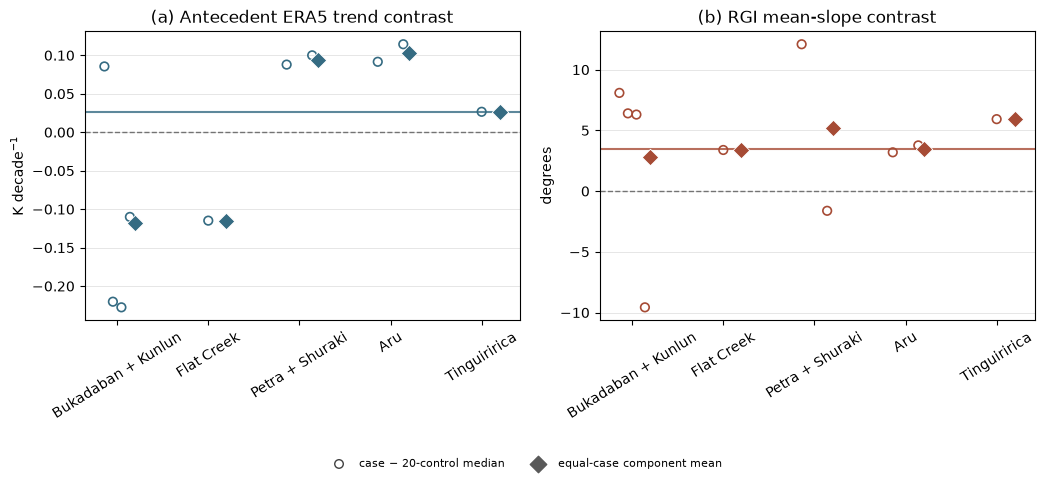

In [2]:
order=sorted(clusters.final_cluster.unique()); labels={'bukadaban-2022':'Bukadaban + Kunlun','flat-creek-2013':'Flat Creek','petra-dp19':'Petra + Shuraki','site-aru':'Aru','tinguiririca-2007':'Tinguiririca'}
panels=[('t2m_trend_k_decade','(a) Antecedent ERA5 trend contrast','K decade$^{-1}$','#356b82'),('slope_deg','(b) RGI mean-slope contrast','degrees','#a64b35')]
fig,axes=plt.subplots(1,2,figsize=(10.6,4.8),sharex=True)
for ax,(endpoint,title,unit,color) in zip(axes,panels):
    case=matched[matched.endpoint.eq(endpoint)]; component=clusters[clusters.endpoint.eq(endpoint)]
    for x,key in enumerate(order):
        values=case.loc[case.final_cluster.eq(key),'contrast'].to_numpy(); offsets=np.linspace(-.14,.14,len(values)) if len(values)>1 else [0]
        ax.scatter(x+np.asarray(offsets),values,s=38,facecolors='none',edgecolors=color,linewidths=1.2,zorder=3)
        value=component.loc[component.final_cluster.eq(key),'contrast'].iloc[0]; ax.scatter(x+.20,value,s=70,marker='D',color=color,edgecolors='white',linewidths=.6,zorder=4)
    med=component.contrast.median(); ax.axhline(0,color='.45',ls='--',lw=1); ax.axhline(med,color=color,lw=1.5,alpha=.8)
    ax.set(title=title,ylabel=unit,xticks=range(len(order)),xticklabels=[labels[k] for k in order]); ax.tick_params(axis='x',rotation=32); ax.grid(axis='y',color='.9',lw=.7)
open_handle=axes[0].scatter([],[],s=38,facecolors='none',edgecolors='.25',label='case − 20-control median'); filled_handle=axes[0].scatter([],[],s=70,marker='D',color='.35',label='equal-case component mean')
fig.legend(handles=[open_handle,filled_handle],frameon=False,fontsize=8,loc='lower center',ncol=2,bbox_to_anchor=(.5,-.01)); fig.tight_layout(rect=(0,.08,1,1)); fig.savefig(root/'figures/glacier_warming_steepness.png',dpi=300,bbox_inches='tight'); fig.savefig(root/'figures/glacier_warming_steepness.pdf',bbox_inches='tight'); plt.show()

**Figure.** Matched contrasts for (a) strictly antecedent 20-year ERA5 2-m-air-temperature trends and (b) mixed-epoch RGI 7 glacier-wide mean surface-slope attributes. Open points are documented cases minus the median of 20 frozen matched RGI comparison objects; filled diamonds are equal-case means within the five final dependence components. Components receive equal weight. Solid lines mark median component contrasts and dashed lines mark zero. ERA5 is regional atmospheric exposure at model orography, and RGI slope combines approximately year-2000 outlines with mixed DEM/source epochs; neither endpoint measures pre-event source geometry or establishes a warming-trigger mechanism.